In [45]:
import pandas as pd
import io
import numpy as np
pd.set_option('display.max_columns', None)
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os, tempfile
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from STICC_solver import STICC
%matplotlib inline
import matplotlib.pyplot as plt
import glob
from datetime import datetime
import umap.umap_ as umap
import torch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from scipy.sparse import lil_matrix
import torch.nn as nn

In [12]:
folder_path = Path("all_fires/")
parquet_files=[]
for file_path in folder_path.iterdir():
  if file_path.is_file():
      if file_path.name.startswith("."):
          continue
      else:
        parquet_files.append(file_path.name)

In [30]:
def getFireDf(datestr):
    collections, fire_masks = [], []
    fire_id=datestr  
    df = pd.read_parquet(f"all_fires/{fire_id}.parquet")
    dates = sorted(df["date"].unique())
    df = df[df["date"].isin(dates)].copy()
    df['date']=df['date'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d').date())
    df = df.sort_values(["x", "y", "date"])
    
    return df, dates
            
def plot_fire(df, dates):
    fire_df = df.copy()
    xmin, xmax = fire_df["x"].min(), fire_df["x"].max()
    ymin, ymax = fire_df["y"].min(), fire_df["y"].max()
    
    ncols = 4
    nrows = int(np.ceil(len(dates) / ncols))
    
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4*ncols, 4*nrows),
        sharex=True,
        sharey=True,
        squeeze=False
    )
    
    for ax, date in zip(axes.flat, dates):
    
        day = fire_df[fire_df["date"] == date]
    
        ax.scatter(
            day["x"],
            day["y"],
            c=day["active_fire"],
            cmap="bwr",
            vmin=0,
            vmax=1,
            marker="s",
            s=10
        )
    
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal", adjustable="box")
    
        ax.set_title(str(date))
    
    for ax in axes.flat[len(dates):]:
        ax.axis("off")
    
    return fig
    


def sw_dbscan(X, metadata, eps=.15, min_pts=4, d=1):
    db = metadata.copy().reset_index(drop=True)
    X = MinMaxScaler().fit_transform(X.reshape(len(X), -1))
    labels = np.full(len(db), -1)
    visited = np.zeros(len(db), bool)
    rows, cols = db["row"].values, db["col"].values
    cid = 0

    def neighbors(i):
        idx = np.where((abs(rows-rows[i]) <= d) & (abs(cols-cols[i]) <= d))[0]
        return idx[np.linalg.norm(X[idx] - X[i], axis=1) <= eps]

    for i in tqdm(range(len(db)), desc="Clustering cells"):
        if visited[i]: continue
        visited[i] = True
        N = neighbors(i)
        if len(N) < min_pts: continue

        labels[i] = cid
        Q = list(N)

        while Q:
            j = Q.pop()
            if not visited[j]:
                visited[j] = True
                Nj = neighbors(j)
                if len(Nj) >= min_pts: Q.extend(Nj)
            if labels[j] == -1: labels[j] = cid

        cid += 1

    db["cluster_id"] = labels
    return db   



def spatial_agglomerative(X, metadata, n_clusters=50, d=1):
    db = metadata.copy().reset_index(drop=True)
    Xf = MinMaxScaler().fit_transform(X.reshape(len(X), -1))

    rows, cols = db["row"].to_numpy(), db["col"].to_numpy()
    pos = {(r, c): i for i, (r, c) in enumerate(zip(rows, cols))}

    conn = lil_matrix((len(db), len(db)), dtype=bool)

    for i, (r, c) in enumerate(zip(rows, cols)):
        for dr in range(-d, d+1):
            for dc in range(-d, d+1):
                if (r+dr, c+dc) in pos:
                    conn[i, pos[(r+dr, c+dc)]] = True

    model = AgglomerativeClustering(
        n_clusters=min(n_clusters, len(db)),
        connectivity=conn.tocsr(),
        linkage="ward"
    )

    db["cluster_id"] = model.fit_predict(Xf)
    return db

def sticc_cluster(db, features, k=5, R=3, beta=3, lam=.01, max_iters=20):
    db = db.dropna(subset=features).copy().reset_index(drop=True)

    if len(db) < max(k, R + 1):
        db["cluster_id"] = -1
        return db

    X = StandardScaler().fit_transform(db[features])

    # R nearest spatial neighbors, excluding the cell itself
    R_eff = min(R, len(db) - 1)

    nn = NearestNeighbors(n_neighbors=R_eff)
    nn.fit(db[["row", "col"]])
    
    neighbors = nn.kneighbors(return_distance=False)

    data = np.hstack([
        np.arange(len(db))[:, None],
        X,
        neighbors
    ])

    with tempfile.NamedTemporaryFile(suffix=".txt", delete=False) as f:
        fname = f.name

    np.savetxt(fname, data, delimiter=",")

    os.makedirs("sticc_output", exist_ok=True)

    model = STICC(
        spatial_radius=R,
        number_of_clusters=k,
        lambda_parameter=lam,
        beta=beta,
        maxIters=max_iters,
        threshold=2e-5,
        write_out_file=False,
        prefix_string="sticc_output/",
        num_proc=1,
        biased=True,
        attr_idx_start=1,
        attr_idx_end=len(features),
        spatial_idx_start=len(features)+1,
        spatial_idx_end=len(features)+R
    )

    labels, mrfs = model.fit(input_file=fname)
    os.remove(fname)

    db["cluster_id"] = np.asarray(labels).astype(int)
    return db

def summarize_fire(df):
    data={
        "fire": df["fire"].iloc[0],
        "n_pixels": df[["row","col"]].drop_duplicates().shape[0],
        "duration_days":len(set(df["date"].to_list())),
        "actual fire days": df["date"].nunique(),
        "wind_mean": df["wind_speed"].mean(),
        "wind_std":  df["wind_speed"].std(),
        "temp_max_mean": df["maximum_temperature"].mean(),
        "temp_max_std":  df["maximum_temperature"].std(),
        "humidity_mean": df["specific_humidity"].mean(),
        "humidity_std":  df["specific_humidity"].std(),
        "erc_mean": df["energy_release_component"].mean(),
        "ndvi_mean": df["ndvi"].mean(),
        "slope_mean": df["slope"].mean(),
        "elevation_mean": df["elevation"].mean(),
    }
    return df, data

In [11]:
observed_dfs = []
future_dfs = []
from tqdm.auto import tqdm
cluster_features = [
    'viirs_m11', 'viirs_i2', 'wind_speed', 'wind_direction',
    'maximum_temperature', 'specific_humidity', 'landcover_class',
    'forecast_wind_direction', 'forecast_temperature',
    'forecast_specific_humidity'
]

obs, future = [], []
for file in tqdm(parquet_files, desc="Processing fires"):
    try:
        df = getFireDf(file.replace(".parquet",""))[0]
        df = df[['fire','date','row','col','longitude','latitude'] + cluster_features]
        df["date"] = pd.to_datetime(df["date"])
        dates = sorted(df["date"].dt.normalize().unique())

        for i in range(len(dates)-4):
            d = dates[i:i+5]
            if all(d[j]-d[j-1] == pd.Timedelta(days=1) for j in range(1,5)):
                temp = df[df["date"].dt.normalize() >= d[0]].copy()
                temp["day_num"] = (temp["date"].dt.normalize() - d[0]).dt.days + 1
                obs.append(temp[temp.day_num <= 5])
                future.append(temp[temp.day_num > 5])
                break

    except Exception as e:
        print("ERROR:", file, e)

observed_df = pd.concat(obs, ignore_index=True)
future_df = pd.concat(future, ignore_index=True)

id="8bk1xg"
id_cols = ["fire","row","col","longitude","latitude"]

wide_df = observed_df.pivot(
    index=id_cols,
    columns="day_num",
    values=cluster_features
)

wide_df.columns = [f"{feature}_d{day}" for feature, day in wide_df.columns]
wide_df = wide_df.reset_index()
wide_df.to_parquet("observed.parquet", compression="zstd")

future_df = future_df.pivot(
    index=id_cols,
    columns="day_num",
    values=cluster_features
)

future_df.columns = [f"{feature}_d{day}" for feature, day in future_df.columns]
future_df = future_df.reset_index()
future_df.to_parquet("future.parquet", compression="zstd")

Processing fires:  32%|███▏      | 64/199 [06:54<12:32,  5.57s/it]

ERROR: 2018_fire_21890078.parquet [Errno 2] No such file or directory: 'all_fires/2018_fire_21890078.parquet'


Processing fires: 100%|██████████| 199/199 [22:17<00:00,  6.72s/it]


In [13]:
observed_df

,fire,date,row,col,longitude,latitude,viirs_m11,viirs_i2,wind_speed,wind_direction,maximum_temperature,specific_humidity,landcover_class,forecast_wind_direction,forecast_temperature,forecast_specific_humidity,day_num
0,fire_23160475,2019-08-02,308,0,-119.067388,47.472628,1757.0,2024.0,4.5,259.0,304.899994,0.00756,10.0,-38.316601,25.502401,0.005868,1
1,fire_23160475,2019-08-03,308,0,-119.067388,47.472628,2380.0,2392.0,2.5,297.0,304.000000,0.00650,10.0,89.493721,25.824633,0.005232,2
2,fire_23160475,2019-08-04,308,0,-119.067388,47.472628,2220.0,2226.0,3.2,205.0,307.100006,0.00535,10.0,88.380043,26.606449,0.005810,3
3,fire_23160475,2019-08-05,308,0,-119.067388,47.472628,2061.0,2301.0,2.7,212.0,309.299988,0.00575,10.0,55.330513,26.558964,0.006452,4
4,fire_23160475,2019-08-06,308,0,-119.067388,47.472628,1682.0,2913.0,2.3,277.0,311.299988,0.00689,10.0,-36.281197,25.927742,0.007483,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78707435,fire_21998103,2018-08-07,0,245,-112.833441,45.597210,1729.0,2384.0,3.8,300.0,295.299988,0.00627,10.0,38.019588,19.668673,0.005117,1
78707436,fire_21998103,2018-08-08,0,245,-112.833441,45.597210,1499.0,1804.0,2.9,276.0,298.200012,0.00628,10.0,20.312014,20.148819,0.004878,2
78707437,fire_21998103,2018-08-09,0,245,-112.833441,45.597210,901.0,1648.0,2.2,244.0,300.500000,0.00599,10.0,43.741611,20.299122,0.005370,3
78707438,fire_21998103,2018-08-10,0,245,-112.833441,45.597210,1302.0,2652.0,2.2,88.0,301.399994,0.00567,10.0,13.037311,19.455542,0.005131,4


In [21]:
id="8bk1xjg"
id_cols = ["fire","row","col","longitude","latitude"]

future_df = future_df.pivot(
    index=id_cols,
    columns="day_num",
    values=cluster_features
)

future_df.columns = [f"{feature}_d{day}" for feature, day in future_df.columns]
future_df = future_df.reset_index()
future_df.to_parquet("future.parquet", compression="zstd")

In [22]:
wide_df

,fire,row,col,longitude,latitude,viirs_m11_d1,viirs_m11_d2,viirs_m11_d3,viirs_m11_d4,viirs_m11_d5,viirs_i2_d1,viirs_i2_d2,viirs_i2_d3,viirs_i2_d4,viirs_i2_d5,wind_speed_d1,wind_speed_d2,wind_speed_d3,wind_speed_d4,wind_speed_d5,wind_direction_d1,wind_direction_d2,wind_direction_d3,wind_direction_d4,wind_direction_d5,maximum_temperature_d1,maximum_temperature_d2,maximum_temperature_d3,maximum_temperature_d4,maximum_temperature_d5,specific_humidity_d1,specific_humidity_d2,specific_humidity_d3,specific_humidity_d4,specific_humidity_d5,landcover_class_d1,landcover_class_d2,landcover_class_d3,landcover_class_d4,landcover_class_d5,forecast_wind_direction_d1,forecast_wind_direction_d2,forecast_wind_direction_d3,forecast_wind_direction_d4,forecast_wind_direction_d5,forecast_temperature_d1,forecast_temperature_d2,forecast_temperature_d3,forecast_temperature_d4,forecast_temperature_d5,forecast_specific_humidity_d1,forecast_specific_humidity_d2,forecast_specific_humidity_d3,forecast_specific_humidity_d4,forecast_specific_humidity_d5
0,fire_21459239,0,0,-113.280105,38.068602,1727.0,2981.0,3599.0,2643.0,2169.0,1665.0,2966.0,6972.0,2003.0,1945.0,3.2,2.7,1.2,2.5,2.1,214.0,225.0,162.0,150.0,249.0,289.899994,290.799988,287.700012,288.899994,288.700012,0.00253,0.00246,0.00311,0.00368,0.00375,10.0,10.0,10.0,10.0,10.0,-66.881737,-12.333782,-4.496344,53.575886,61.343643,7.066679,7.594994,7.442619,6.533696,5.732845,0.003243,0.003458,0.003674,0.003515,0.003369
1,fire_21459239,0,1,-113.275891,38.068250,1727.0,2981.0,3599.0,2643.0,2169.0,1665.0,2966.0,6972.0,2003.0,1945.0,3.2,2.7,1.2,2.5,2.1,214.0,225.0,162.0,150.0,249.0,289.899994,290.799988,287.700012,288.899994,288.700012,0.00253,0.00246,0.00311,0.00368,0.00375,10.0,10.0,10.0,10.0,10.0,-66.881737,-12.333782,-4.496344,53.575886,61.343643,7.066679,7.594994,7.442619,6.533696,5.732845,0.003243,0.003458,0.003674,0.003515,0.003369
2,fire_21459239,0,2,-113.271677,38.067898,1727.0,2981.0,3599.0,2643.0,2169.0,1726.0,3075.0,6968.0,2123.0,2070.0,3.2,2.7,1.2,2.5,2.1,214.0,225.0,162.0,150.0,249.0,289.899994,290.799988,287.700012,288.899994,288.700012,0.00253,0.00246,0.00311,0.00368,0.00375,10.0,10.0,10.0,10.0,10.0,-66.881737,-12.333782,-4.496344,53.575886,61.343643,7.066679,7.594994,7.442619,6.533696,5.732845,0.003243,0.003458,0.003674,0.003515,0.003369
3,fire_21459239,0,3,-113.267464,38.067546,1479.0,2830.0,3677.0,2248.0,2169.0,1713.0,3084.0,7065.0,2050.0,2059.0,3.2,2.7,1.2,2.5,2.1,214.0,225.0,162.0,150.0,249.0,289.899994,290.799988,287.700012,288.899994,288.700012,0.00253,0.00246,0.00311,0.00368,0.00375,10.0,10.0,10.0,10.0,10.0,-66.881737,-12.333782,-4.496344,53.575886,61.343643,7.066679,7.594994,7.442619,6.533696,5.732845,0.003243,0.003458,0.003674,0.003515,0.003369
4,fire_21459239,0,4,-113.263250,38.067193,1479.0,2830.0,3677.0,2248.0,2169.0,1757.0,3160.0,7175.0,1989.0,2018.0,3.2,2.7,1.2,2.5,2.1,214.0,225.0,162.0,150.0,249.0,289.899994,290.799988,287.700012,288.899994,288.700012,0.00253,0.00246,0.00311,0.00368,0.00375,10.0,10.0,10.0,10.0,10.0,-66.881737,-12.333782,-4.496344,53.575886,61.343643,7.066679,7.594994,7.442619,6.533696,5.732845,0.003243,0.003458,0.003674,0.003515,0.003369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15741483,fire_24695758,307,226,-118.172315,43.306561,1659.0,3714.0,1493.0,1444.0,1586.0,3028.0,5811.0,2324.0,2294.0,2168.0,3.0,2.8,2.2,3.4,3.0,81.0,234.0,313.0,75.0,81.0,277.500000,277.799988,276.000000,276.899994,278.299988,0.00260,0.00239,0.00231,0.00219,0.00196,10.0,10.0,10.0,10.0,10.0,-16.304518,-14.913677,-12.995762,-6.305778,31.882391,-0.890244,-1.066540,-1.401507,-1.674445,-0.530339,0.002686,0.002345,0.002203,0.002592,0.002817
15741484,fire_24695758,307,227,-118.167708,43.306366,2267.0,3870.0,1477.0,1444.0,1643.0,3986.0,5501.0,2510.0,2050.0,2404.0,3.0,2.8,2.2,3.4,3.0,81.0,234.0,313.0,75.0,81.0,277.500000

In [23]:
X = np.stack([
    wide_df[[f"{f}_d{d}" for f in cluster_features]].to_numpy(np.float32)
    for d in range(1, 6)
], axis=1)

cell_info = wide_df[["fire","row","col","longitude","latitude"]]

print(X.shape)
# (15741488, 5, 10) means 15741488 cells 5 days 10 features

(15741488, 5, 10)


In [24]:
np.save("X_observed.npy", X)
metadata = wide_df[
    ["fire", "row", "col", "longitude", "latitude"]
].reset_index(drop=True)

assert len(metadata) == X.shape[0]
metadata.to_parquet("X_observed_metadata.parquet", index=False)

In [25]:
X = np.load("X_observed.npy")
metadata = pd.read_parquet("X_observed_metadata.parquet")

print(X.shape)
print(metadata.shape)
print(metadata.head())

(15741488, 5, 10)
(15741488, 5)
            fire  row  col   longitude   latitude
0  fire_21459239    0    0 -113.280105  38.068602
1  fire_21459239    0    1 -113.275891  38.068250
2  fire_21459239    0    2 -113.271677  38.067898
3  fire_21459239    0    3 -113.267464  38.067546
4  fire_21459239    0    4 -113.263250  38.067193


In [35]:
Xf = X.reshape(len(X), -1)
Xf = SimpleImputer(strategy="median").fit_transform(Xf)
Xf = MinMaxScaler().fit_transform(Xf)

In [64]:
from tqdm import tqdm

results = []

for fire in tqdm(metadata["fire"].unique(), desc="Clustering fires"):
    mask = metadata["fire"].eq(fire).to_numpy()

    X_fire = Xf[mask]
    metadata_fire = metadata.loc[mask].reset_index(drop=True)

    clustered_fire = spatial_agglomerative(
        X_fire,
        metadata_fire,
        n_clusters=20,
        d=1
    )

    results.append(clustered_fire)

clustered = pd.concat(results, ignore_index=True)

Clustering fires: 100%|██████████| 198/198 [28:50<00:00,  8.74s/it]


In [75]:
clustered.to_parquet("clustered.parquet")

In [65]:
import random
ufires=list(set(clustered['fire'].to_list()))
query_fires = random.sample(ufires, k=6)
candidate_fires = [i for i in ufires if i not in query_fires]

print(len(query_fires))
print(len(candidate_fires))

6
192


In [66]:
# Impute X once, keep original shape
X_clean = SimpleImputer(strategy="median").fit_transform(
    X.reshape(len(X), -1)
).reshape(X.shape)

region_X = []
region_info = []

valid = clustered["cluster_id"].ne(-1)

for (fire, cid), group in clustered[valid].groupby(["fire", "cluster_id"]):
    idx = group.index.to_numpy()
    region = X_clean[idx].mean(axis=0)

    region_X.append(region)
    region_info.append([fire, cid, len(idx)])

region_X = np.stack(region_X)

region_info = pd.DataFrame(
    region_info,
    columns=["fire", "cluster_id", "n_cells"]
)

print(region_X.shape)
print("NaNs:", np.isnan(region_X).sum()) 
print(region_info.head())

(3960, 5, 10)
NaNs: 0
            fire  cluster_id  n_cells
0  fire_21459239           0     6780
1  fire_21459239           1     6058
2  fire_21459239           2     4514
3  fire_21459239           3     3905
4  fire_21459239           4     4362


In [67]:
print("region_X before:", np.isnan(region_X).sum())

R = region_X.reshape(region_X.shape[0], -1)

print("R after reshape:", np.isnan(R).sum())

region_X before: 0
R after reshape: 0


In [68]:


R = region_X.reshape(region_X.shape[0], -1)

candidate_mask = region_info["fire"].isin(candidate_fires).to_numpy()
query_mask = region_info["fire"].isin(query_fires).to_numpy()

R_candidate = R[candidate_mask]
R_query = R[query_mask]

# Learn scaling only from candidate fires
scaler = StandardScaler()
R_candidate = scaler.fit_transform(R_candidate)
R_query = scaler.transform(R_query)

# PyTorch tensors
X_candidate = torch.tensor(R_candidate, dtype=torch.float32)
X_query = torch.tensor(R_query, dtype=torch.float32)

print("Candidate:", X_candidate.shape)
print("Query:", X_query.shape)

Candidate: torch.Size([3840, 50])
Query: torch.Size([120, 50])


In [69]:
print("R:", np.isnan(R).sum())
print("R_candidate:", np.isnan(R_candidate).sum())
print("X_candidate:", torch.isnan(X_candidate).sum())

R: 0
R_candidate: 0
X_candidate: tensor(0)


In [70]:
class Autoencoder(nn.Module):
    def __init__(self, n_features, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, n_features)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))
print(torch.isnan(X_candidate).sum())  # must be tensor(0)
model = Autoencoder(X_candidate.shape[1], latent_dim=4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(500):
    optimizer.zero_grad()
    reconstructed = model(X_candidate)
    loss = loss_fn(reconstructed, X_candidate)
    loss.backward()
    optimizer.step()

print("Final loss:", loss.item())

tensor(0)
Final loss: 0.3919040858745575


In [71]:
model.eval()

with torch.no_grad():
    Z_candidate = model.encoder(X_candidate).numpy()
    Z_query = model.encoder(X_query).numpy()

print("Candidate:", X_candidate.shape, "is", Z_candidate.shape)
print("Query:", X_query.shape, "is", Z_query.shape)

Candidate: torch.Size([3840, 50]) is (3840, 4)
Query: torch.Size([120, 50]) is (120, 4)


In [72]:
from sklearn.neighbors import NearestNeighbors

candidate_info = region_info[region_info["fire"].isin(candidate_fires)].reset_index(drop=True)

query_info = region_info[region_info["fire"].isin(query_fires)].reset_index(drop=True)


knn = NearestNeighbors(metric="cosine")
knn.fit(Z_candidate)

def retrieve(query_i, k=5):
    dists, inds = knn.kneighbors(
        Z_query[query_i:query_i+1],
        n_neighbors=k
    )

    results = candidate_info.iloc[inds[0]].copy()
    results["similarity"] = 1 - dists[0]

    print("Query:")
    print(query_info.iloc[query_i])

    return results

retrieve(0, k=5)

Query:
fire          fire_21890160
cluster_id                0
n_cells                4473
Name: 0, dtype: object


,fire,cluster_id,n_cells,similarity
1359,fire_21998100,19,1736,0.992047
3453,fire_24332954,13,6683,0.990328
1387,fire_21998119,7,3976,0.988896
296,fire_21804883,16,2193,0.986740
1389,fire_21998119,9,5740,0.984231


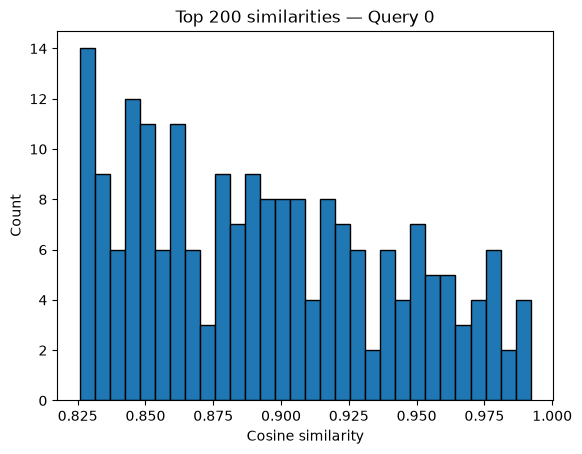

In [73]:
import matplotlib.pyplot as plt

def similarity_distribution(query_i, k=200):
    dists, _ = knn.kneighbors(
        Z_query[query_i:query_i+1],
        n_neighbors=k
    )

    sims = 1 - dists[0]

    plt.hist(sims, bins=30, edgecolor="black")
    plt.xlabel("Cosine similarity")
    plt.ylabel("Count")
    plt.title(f"Top {k} similarities — Query {query_i}")
    plt.show()

    return sims

sims = similarity_distribution(0, 200)

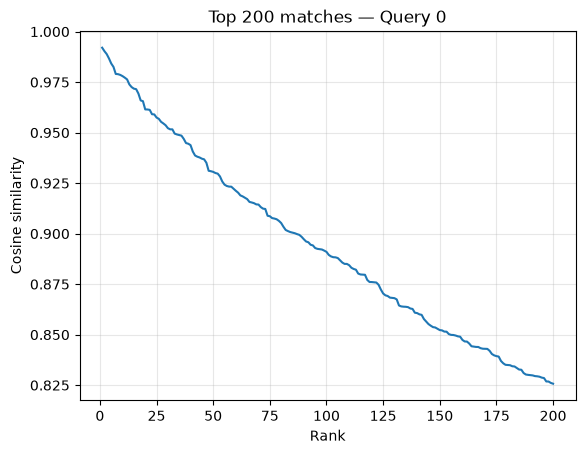

In [74]:
import matplotlib.pyplot as plt

def plot_ranked_similarity(query_i, k=200):
    dists, _ = knn.kneighbors(
        Z_query[query_i:query_i+1],
        n_neighbors=k
    )

    sims = 1 - dists[0]

    plt.plot(range(1, k+1), sims)
    plt.xlabel("Rank")
    plt.ylabel("Cosine similarity")
    plt.title(f"Top {k} matches — Query {query_i}")
    plt.grid(alpha=.3)
    plt.show()

plot_ranked_similarity(0, 200)

/home/ravim/.conda/envs/fire-research/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Query:
fire          fire_21890160
cluster_id                0
n_cells                4473
Name: 0, dtype: object


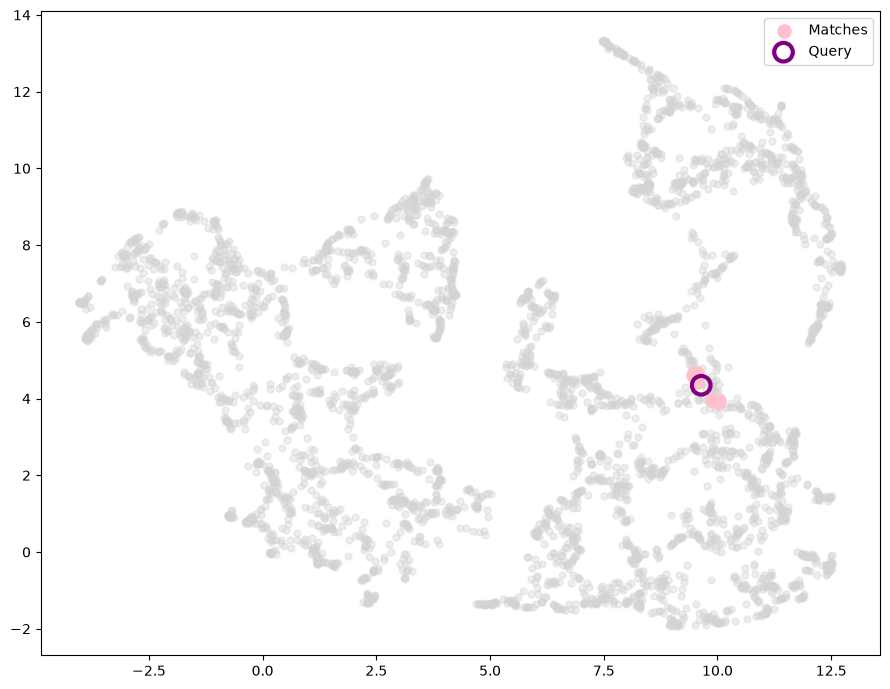

In [76]:
E = np.vstack([Z_query, Z_candidate])
U = umap.UMAP(n_neighbors=15, min_dist=.1, metric="cosine", random_state=42).fit_transform(E)

query_idx = 0
matches = retrieve(query_idx, k=5)
match_idx = matches.index.to_numpy() + len(Z_query)

plt.figure(figsize=(9,7))
plt.scatter(U[:,0], U[:,1], c="lightgray", s=25, alpha=.4)
plt.scatter(U[match_idx,0], U[match_idx,1], c="pink", s=90, label="Matches")
plt.scatter(U[query_idx,0], U[query_idx,1], facecolors="none", edgecolors="purple", linewidths=3, s=180, label="Query")
plt.legend()
plt.tight_layout()
plt.show()

Query:
fire          fire_21890160
cluster_id                0
n_cells                4473
Name: 0, dtype: object


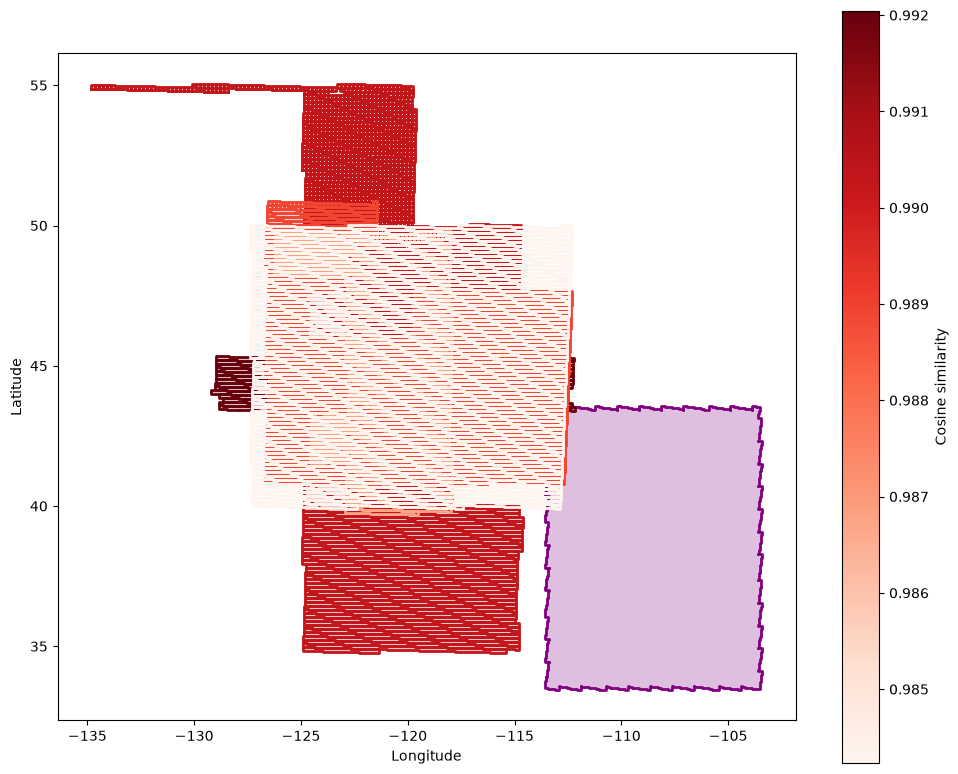

In [79]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from shapely.geometry import box
from shapely.ops import unary_union
from shapely.affinity import scale
import numpy as np

def plot_matches(query_idx, clustered, query_info, retrieve, k=5):
    matches = retrieve(query_idx, k=k)
    rows = [query_info.iloc[query_idx]] + [r for _, r in matches.iterrows()]

    fig, ax = plt.subplots(figsize=(10,8))
    MAG = 40

    sims = matches["similarity"].to_numpy()
    norm = colors.Normalize(vmin=sims.min(), vmax=sims.max())
    cmap = plt.cm.Reds

    for j, r in enumerate(rows):
        pts = clustered[
            (clustered["fire"] == r["fire"]) &
            (clustered["cluster_id"] == r["cluster_id"])
        ]

        lat = pts["latitude"].mean()
        dy = 375 / 111320
        dx = 375 / (111320 * np.cos(np.radians(lat)))

        shape = unary_union([
            box(lon-dx/2, la-dy/2, lon+dx/2, la+dy/2)
            for lon, la in zip(pts.longitude, pts.latitude)
        ])

        shape = scale(shape, xfact=MAG, yfact=MAG, origin="centroid")
        color = "purple" if j == 0 else cmap(norm(r["similarity"]))

        for g in (shape.geoms if shape.geom_type == "MultiPolygon" else [shape]):
            x, y = g.exterior.xy
            ax.fill(x, y, color=color, alpha=.25)
            ax.plot(x, y, color=color, lw=2)

    mean_lat = clustered["latitude"].mean()
    ax.set_aspect(1 / np.cos(np.radians(mean_lat)))

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    plt.colorbar(sm, ax=ax, label="Cosine similarity")

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()
plot_matches(0, clustered, query_info, retrieve, k=5)